
## Resumen

### Población:
La población de interés para este estudio comprende todos los accidentes vehiculares que se han registrado en los Estados Unidos desde el inicio del año 2016 hasta la fecha más reciente disponible en nuestro conjunto de datos.

### Muestra:
Para los propósitos de este estudio, hemos restringido nuestro análisis a una muestra específica. Esta muestra consiste en accidentes vehiculares que se han registrado en el estado de California a partir del año 2022.


## Diccionario de variables 

- ID: Identificador único de incidente

- Source: Fuente de la información

- Severity: Muestra la severidad del accidente, siendo 1 el menor impacto y 4 el  mayor.

- Start time y End Time: Tiempo de inicio y finalización del accidente.

- Start Lat, Start Lng, End Lat y End Lng: Latitudes y longitudes iniciales y finales.

- Distance: La longitud de la carretera recorrida en el incidente.

- Description: Descripción del accidente

- Street: Nombre de la calle del accidente.

- City, County, State, Country:  Ciudad, Condado, Estado y País.

- Zipcode: Código postal de la ubicación del accidente.

- Timezone: Zona de tiempo basado en la localización del accidente.

- Airport_Code: Código del aeropuerto.

- Weather_Timestamp:  Marca de tiempo del registro de observación meteorológica

- Wind_Chill (F),  Temperature (F), Humidity (%), Pressure (in), Wind direction (mph), Precipitation (in), Weather condition: Condiciones del ambiente de viento frío, humedad, presión, dirección del viento, precipitación.

- Visibility (mi): Visibilidad en millas.

- Amenity, Bump, Crossing, Give_way, Junction, No Exit, Roundabout, Station, Stop, Traffic Calming, Traffic_Signal, Turning_Loop:

Indica la presencia de una amenidad, baches, cruce, ceda el paso, unión, no salida, rotonda, estación, pare, pacificación del tráfico, señal de tráfico, bucle giratorio.


## EDA

In [213]:
import pandas as pd
import numpy as np
import klib
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import folium
import calendar

In [214]:
warnings.filterwarnings("ignore")

In [215]:
path = r"C:\Users\jose_\OneDrive\Documentos guardados\Maestria analisis de datos\Machine Learning Likni\Machine learning Likir\Informe_Machine_Learning\US_Accidents_March23.csv"
df =pd.read_csv(path)

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

Los datos iniciales constan de 7.728.394 de datos con 46 columnas, de las cuales 20 son categóricas, 13 booleanas y 13 númericas.

In [217]:
#Reducir el uso de la memoria
def reduce_mem_usage(df):

    start_mem = df.memory_usage(index=True, deep=True).sum() / 1024**2
    start_mem_GB = df.memory_usage(index=True, deep=True).sum() / 1024**3
    print(f'Initial memory usage of dataframe is {start_mem:.2f} MB/{start_mem_GB:.2f} GB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage(index=True, deep=True).sum() / 1024**2
    end_mem_GB = df.memory_usage(index=True, deep=True).sum() / 1024**3
    reduction = 100 * (start_mem - end_mem) / start_mem
    print(f'Memory usage after optimization is: {end_mem:.2f} MB/{end_mem_GB:.2f} GB')
    print(f'Decreased by {reduction:.1f}%')
    
    return df

In [218]:
df = reduce_mem_usage(df)

Initial memory usage of dataframe is 10870.28 MB/10.62 GB
Memory usage after optimization is: 3582.58 MB/3.50 GB
Decreased by 67.0%


In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   ID                     category
 1   Source                 category
 2   Severity               int8    
 3   Start_Time             category
 4   End_Time               category
 5   Start_Lat              float16 
 6   Start_Lng              float16 
 7   End_Lat                float16 
 8   End_Lng                float16 
 9   Distance(mi)           float16 
 10  Description            category
 11  Street                 category
 12  City                   category
 13  County                 category
 14  State                  category
 15  Zipcode                category
 16  Country                category
 17  Timezone               category
 18  Airport_Code           category
 19  Weather_Timestamp      category
 20  Temperature(F)         float16 
 21  Wind_Chill(F)          float16 

In [220]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')


# se crean nuevos ajustes para estandarizar las fechas

In [226]:

df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day
df['Day_Name'] = df['Start_Time'].dt.day_name()
df['Week'] = df['Start_Time'].dt.isocalendar().week
df['Month'] = df['Start_Time'].dt.month
df['Count'] = 1


Text(0.5, 1.0, 'Monthly Accident Count')

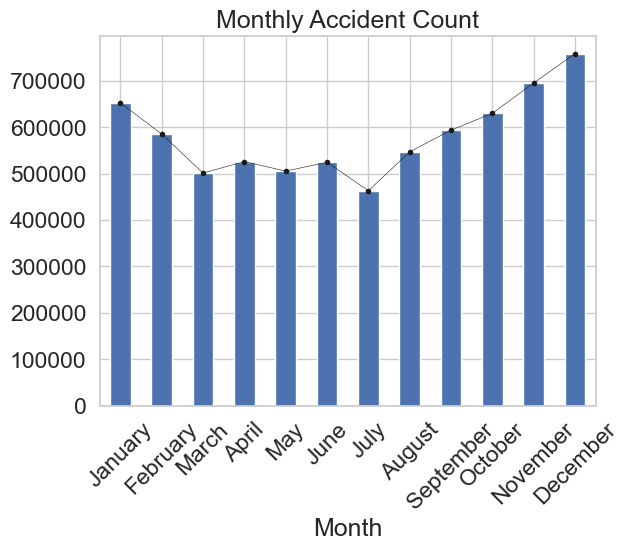

In [227]:

df.groupby('Month')['Count'].value_counts().plot(kind='bar')
df.groupby('Month')['Count'].value_counts().plot(color='k',linestyle='-',marker='.',linewidth=0.4)
plt.xticks(np.arange(12),calendar.month_name[1:13],rotation=45)
plt.xlabel('Month')
plt.title('Monthly Accident Count')

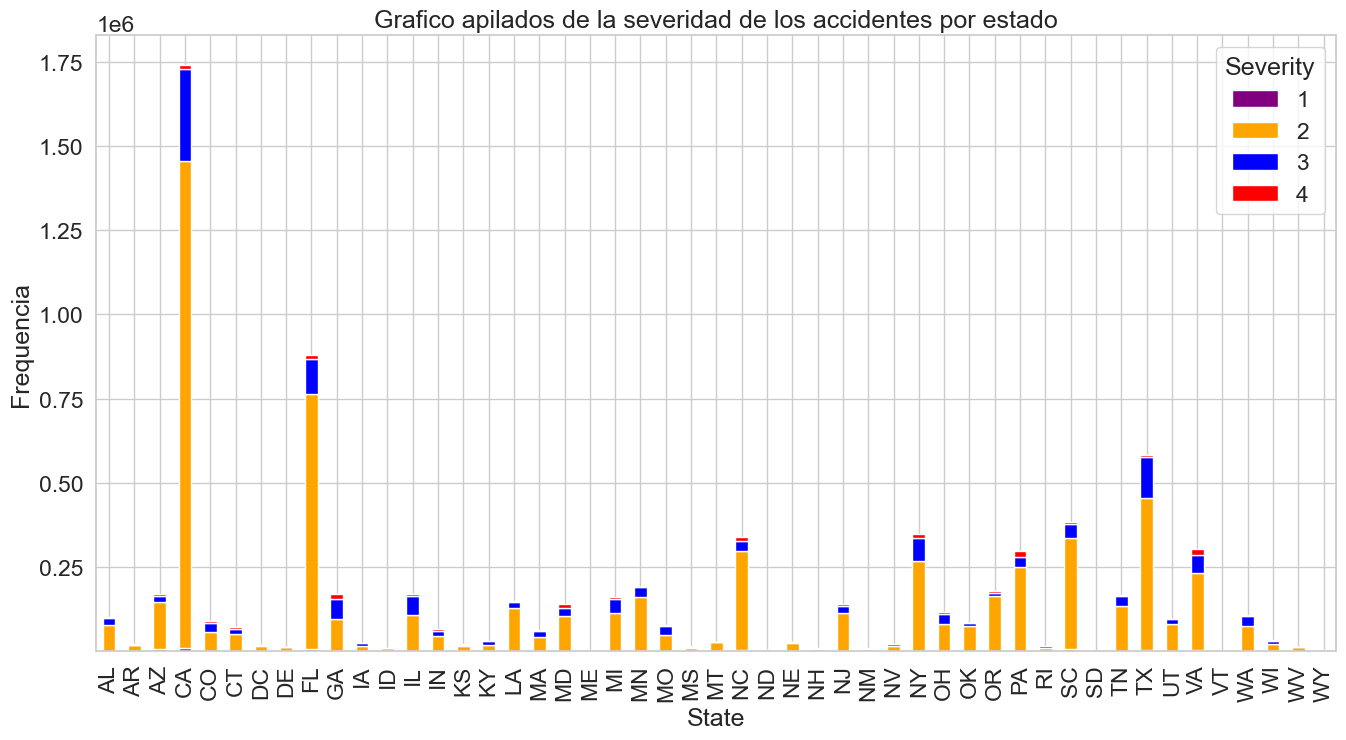

In [228]:
#Creamos una tabla de frecuencia Severidad vs los estados
cat_var = pd.crosstab(columns=df['Severity'],
    index=df['State'])

cat_var.plot(kind='bar',stacked=True,figsize=(16,8),color=['purple','orange','blue','red','green'])
plt.title('Grafico apilados de la severidad de los accidentes por estado')
plt.ylabel('Frequencia')
plt.show()

Como se muestra en la grafica podemos observar que Califormia es el estado que mas accidentes se hayan registrado, siendo la severidad #2 que mas se repite.

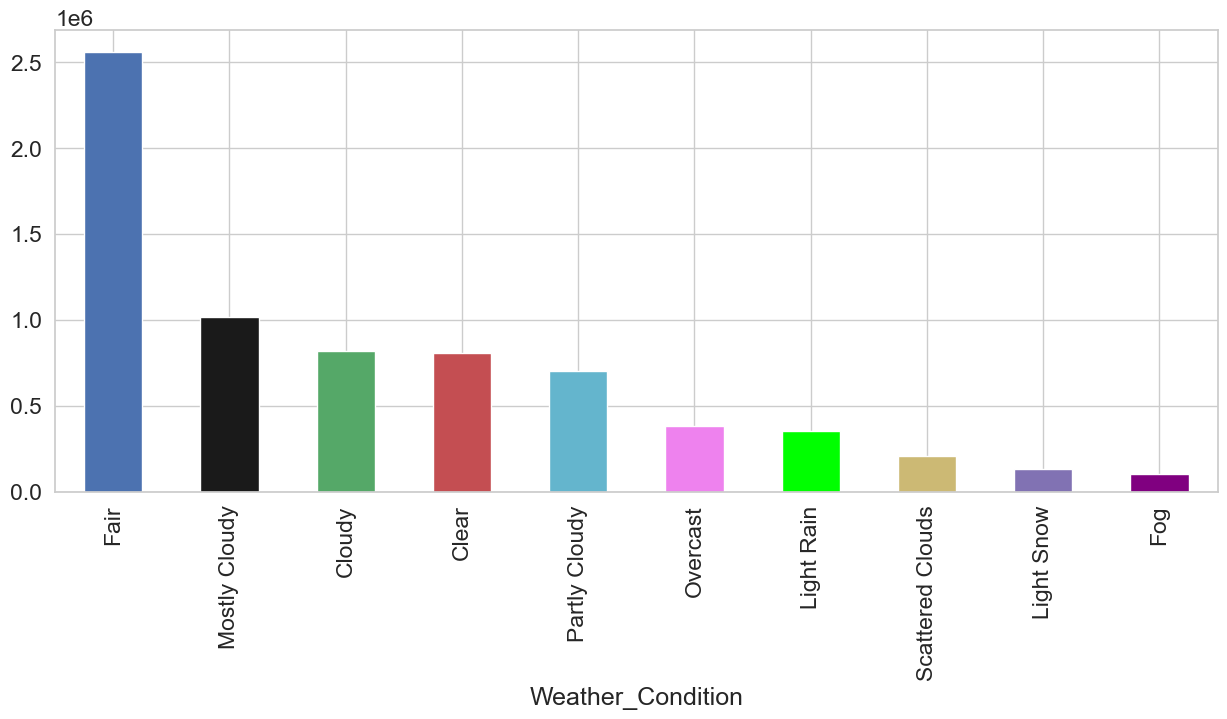

In [229]:
# Top 10 weather condition
plt.figure(figsize = (15, 6))
df[df['Weather_Condition'] != 0]['Weather_Condition'].value_counts().iloc[:10].plot(
    kind='bar',color=['b','k','g','r','c','violet','lime','y','m','purple'])
plt.show()

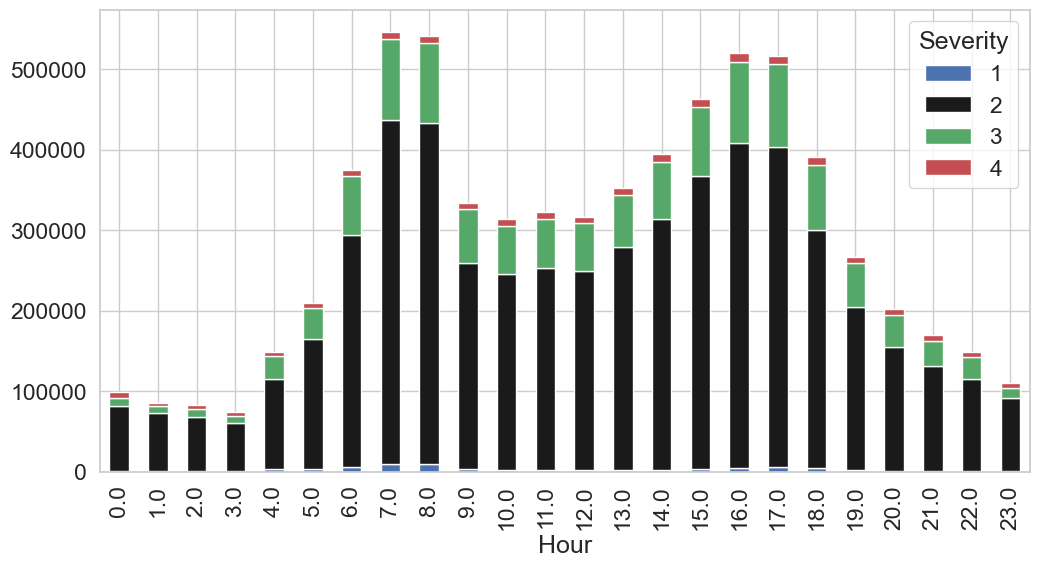

In [231]:
x = pd.crosstab(index=df['Hour'],columns=df['Severity'])
x.plot(kind='bar',stacked=True, color=['b','k','g','r','c'],figsize=(12,6))
plt.show()

Esta grafica es muy diciente, ya que al ser grafica de barras apiladas se pude interpretar las cantidades de accidientes en las horas ocurridas con el gradi deseveridad, siendo de 6am hasta las 8am y 4pm hasta 5pm los picos mas altos que se presentan accidentes, tiene mucho sentido ya que es la hora en la mayoria de los condutores salen a sus trabajos y regresan en las horas de mayor frecuencia.

In [232]:
w = df.groupby(['State'])['Count'].sum().reset_index()

In [233]:
import plotly.express as px
import json

In [234]:
state_geo = r'C:\Users\jose_\OneDrive\Documentos guardados\Maestria analisis de datos\Machine Learning Likni\Machine learning Likir\Informe_Machine_Learning\Json.json'

In [235]:
n = folium.Map(location=[39.381266, -97.922211],zoom_start=5)
folium.Choropleth(
 geo_data=state_geo,
 data=w,
 columns=['State', 'Count'],
 key_on='feature.id',
 fill_color='YlOrRd',
 fill_opacity=0.7,
 line_opacity=0.2,
 legend_name='Accidentes'
).add_to(n)
n

El mapa nos muestra lo que los numeros han evidenciado, que Califorma es el estado con mayor numero de accientes registrado desde el año 2022, de tal forma que se puede persivir de color mas oscuro por la cantidad de accidentes.

In [236]:
conteo= df["State"].value_counts()
print(conteo)
#conteo[:10]

State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
AZ     170609
GA     169234
IL     168958
TN     167388
MI     162191
LA     149701
NJ     140719
MD     140417
OH     118115
WA     108221
AL     101044
UT      97079
CO      90885
OK      83647
MO      77323
CT      71005
IN      67224
MA      61996
WI      34688
KY      32254
NE      28870
MT      28496
IA      26307
AR      22780
NV      21665
KS      20992
DC      18630
RI      16971
MS      15181
DE      14097
WV      13793
ID      11376
NM      10325
NH      10213
WY       3757
ND       3487
ME       2698
VT        926
SD        289
Name: count, dtype: int64


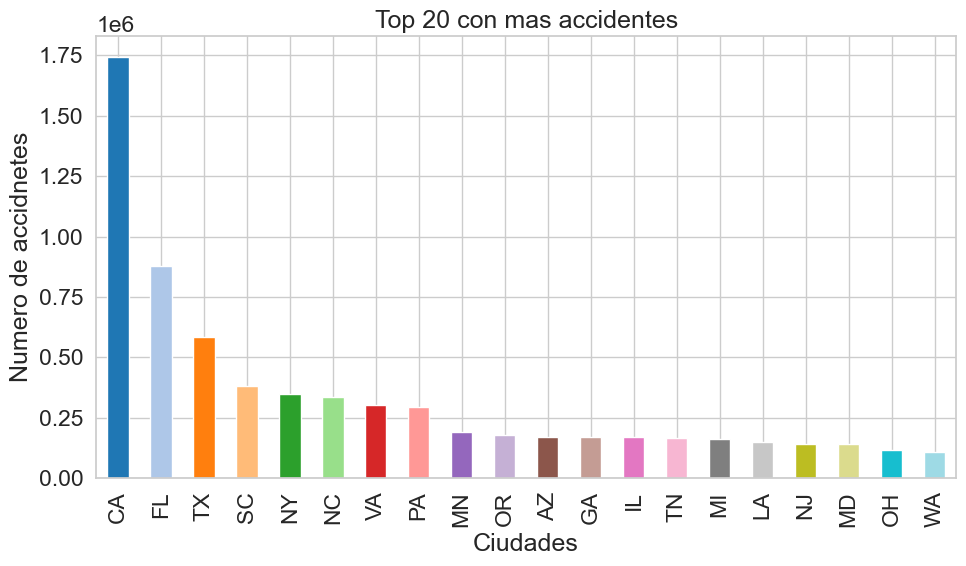

In [237]:

plt.figure(figsize=(10, 6))
color_range = range(50)
top_20_cities.plot(kind='bar', color=plt.get_cmap('tab20')(range(len(color_range))))

plt.title('Top 20 con mas accidentes')
plt.xlabel('Ciudades')
plt.ylabel('Numero de accidnetes')

plt.tight_layout()
plt.show()

Se escoge el estado con mayor número de incidentes registrados, es decir, California.

In [238]:
state='CA'

df=df.loc[df.State==state].copy()
df.drop('State',axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1741433 entries, 728 to 7728393
Data columns (total 51 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   ID                     category      
 1   Source                 category      
 2   Severity               int8          
 3   Start_Time             datetime64[ns]
 4   End_Time               category      
 5   Start_Lat              float16       
 6   Start_Lng              float16       
 7   End_Lat                float16       
 8   End_Lng                float16       
 9   Distance(mi)           float16       
 10  Description            category      
 11  Street                 category      
 12  City                   category      
 13  County                 category      
 14  Zipcode                category      
 15  Country                category      
 16  Timezone               category      
 17  Airport_Code           category      
 18  Weather_Timestamp      ca

In [239]:
accidents_severity = df.groupby('Severity').count()['ID']
accidents_severity

Severity
1      10284
2    1445833
3     271814
4      13502
Name: ID, dtype: int64

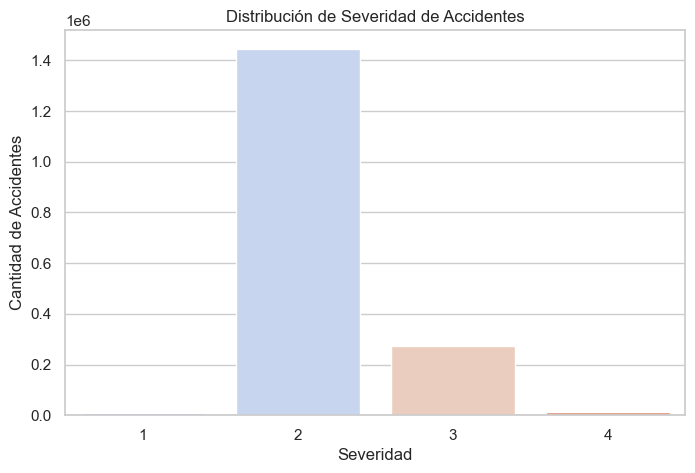

In [240]:
# Configurar gráficos de Seaborn
sns.set(style="whitegrid")

# Gráfico de distribución de severidad de accidentes
plt.figure(figsize=(8, 5))
sns.countplot(x=df["Severity"], palette="coolwarm")
plt.title("Distribución de Severidad de Accidentes")
plt.xlabel("Severidad")
plt.ylabel("Cantidad de Accidentes")
plt.show()


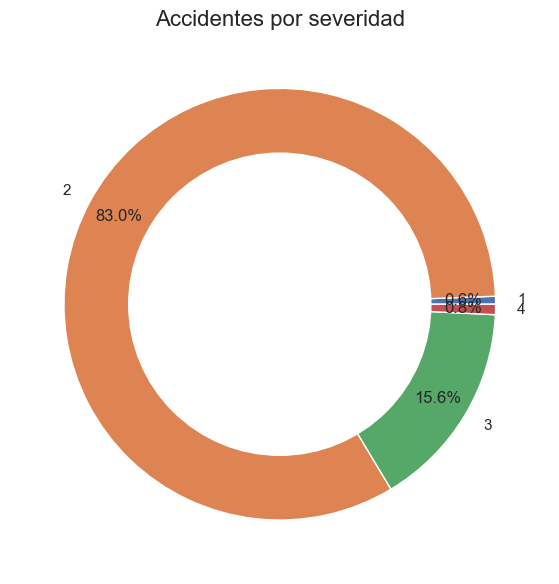

In [241]:

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(aspect="equal"))
label = [1,2,3,4]
plt.pie(accidents_severity, labels=label,
        autopct='%1.1f%%', pctdistance=0.85)
circle = plt.Circle( (0,0), 0.7, color='white')
p=plt.gcf()
p.gca().add_artist(circle)
ax.set_title("Accidentes por severidad",fontdict={'fontsize': 16})
plt.tight_layout()
plt.show()

El 0,8% de los accidentes han sido muy severos indicando como el grado 4

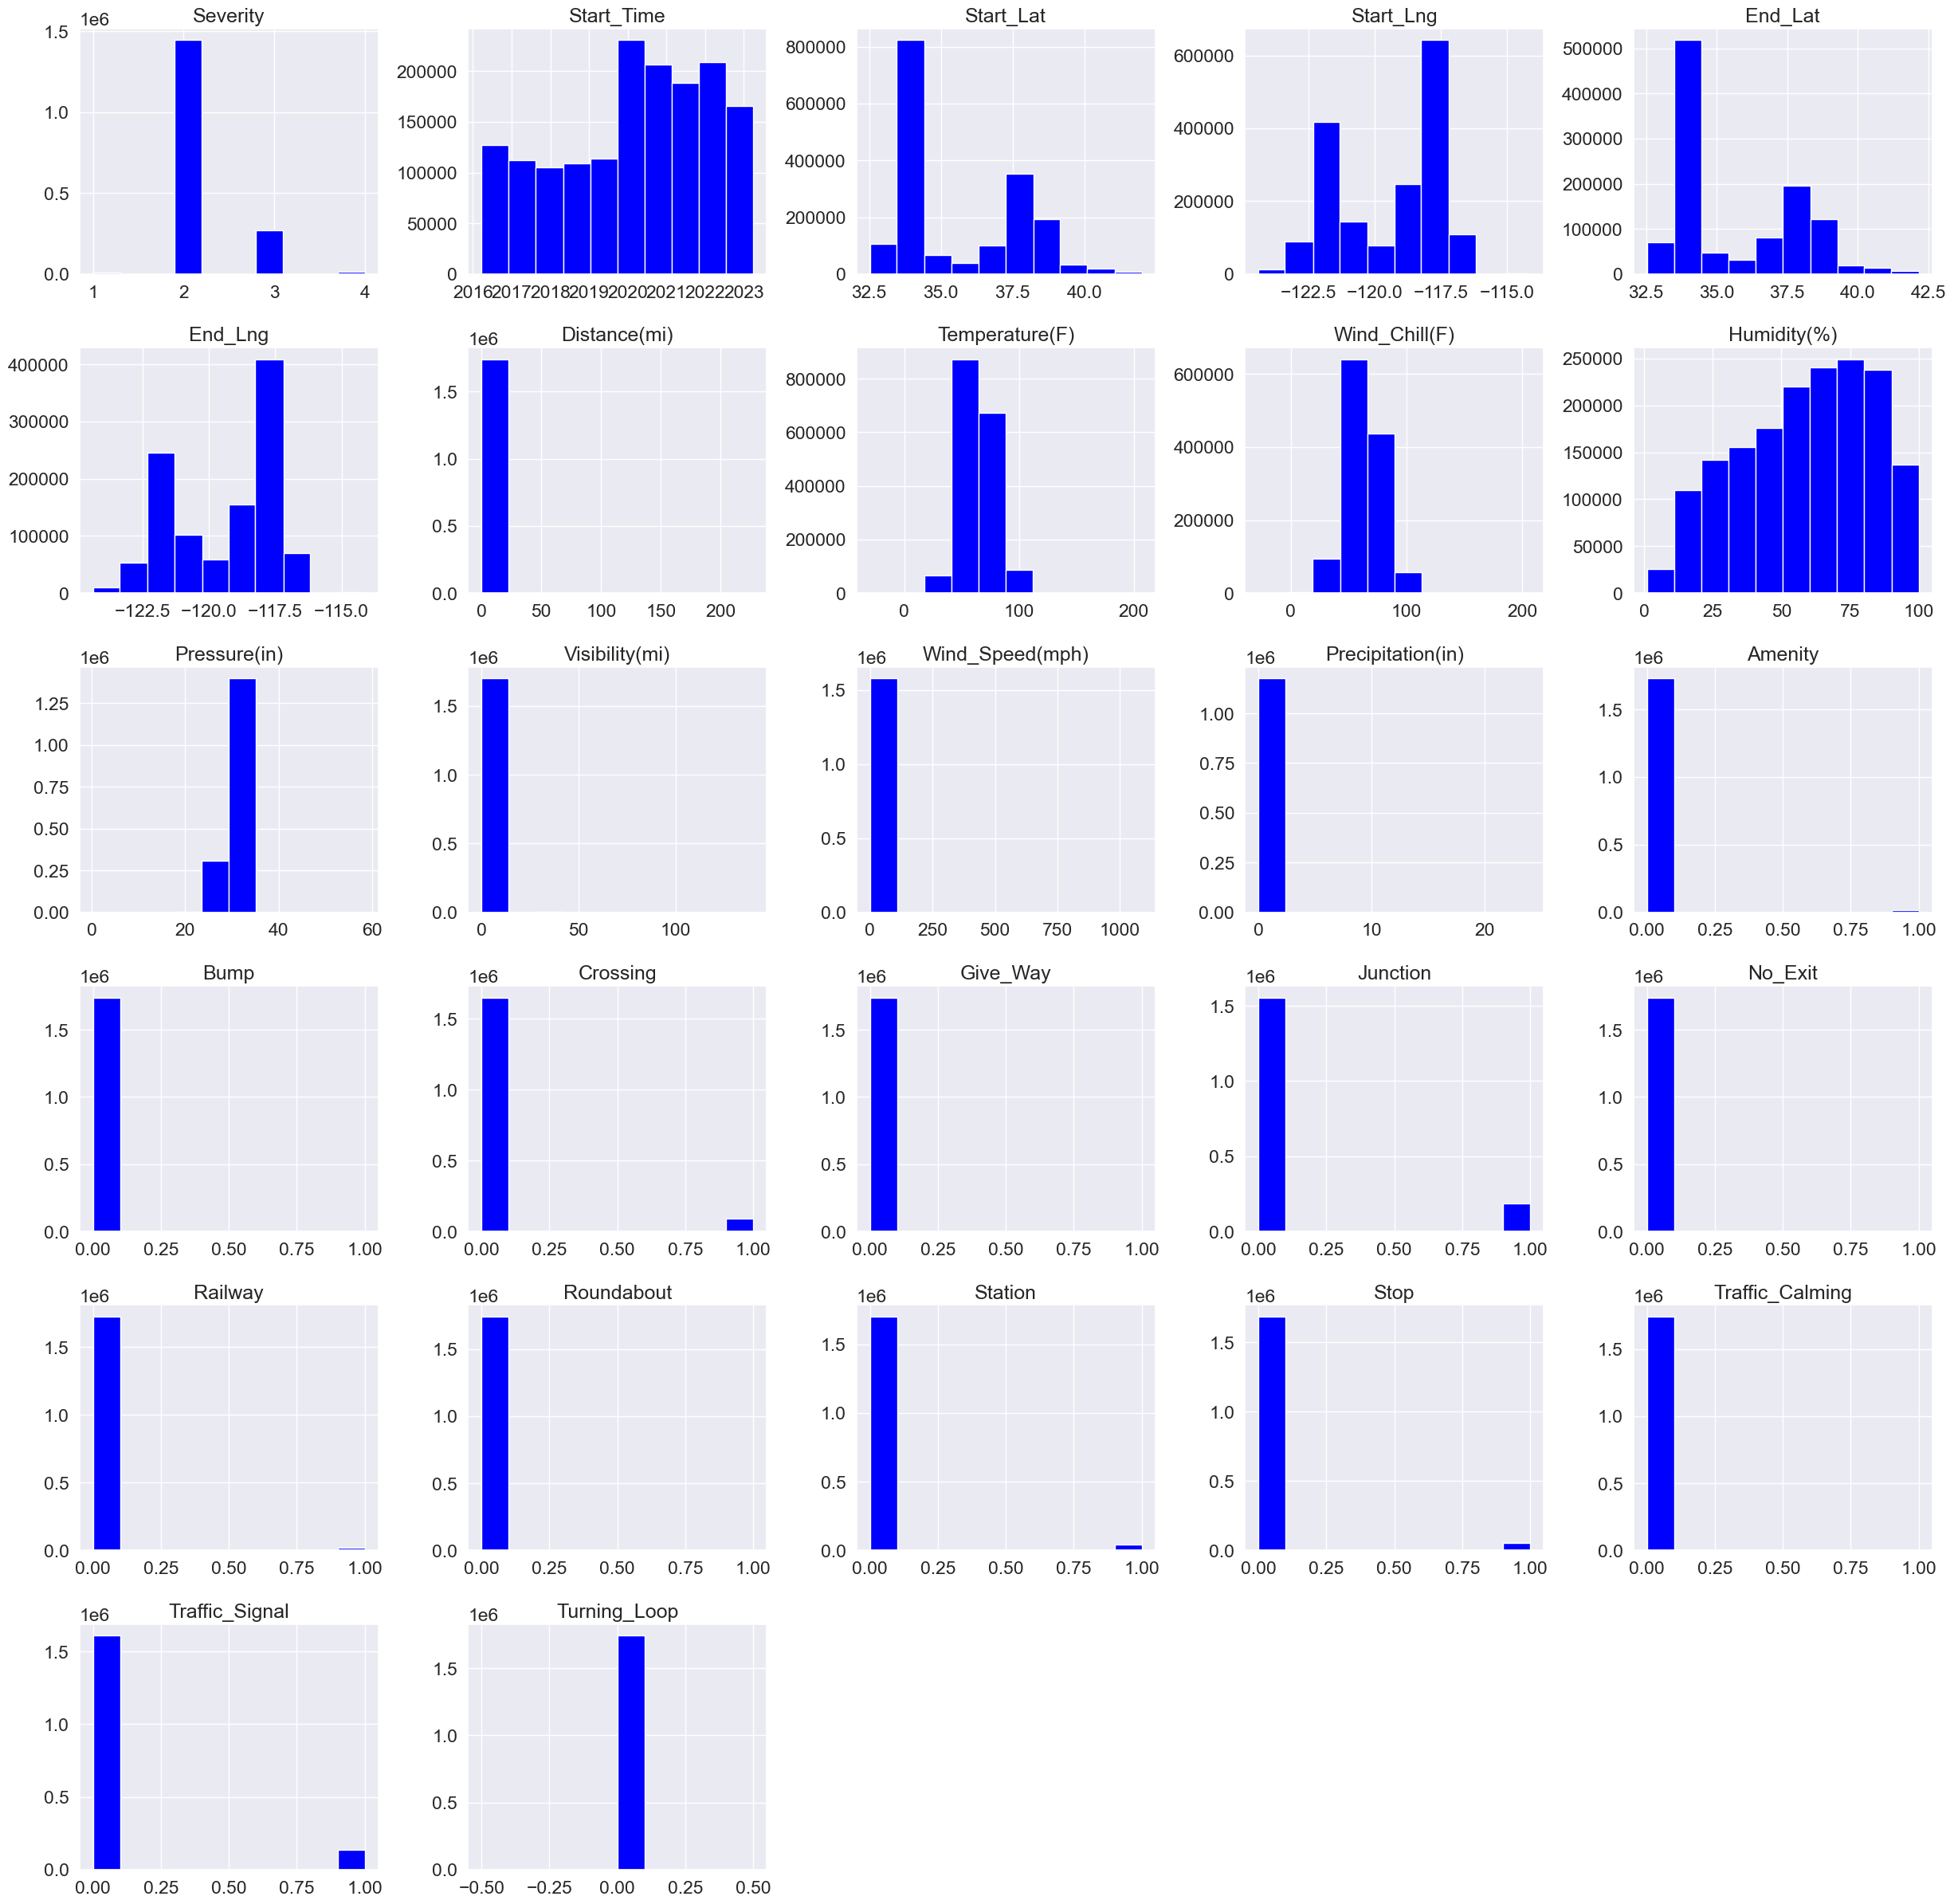

In [242]:
sns.set(font_scale=1.5)
df.iloc[: , 1:-6].hist(figsize = (30,30), color = 'blue');

Se remueven las siguientes columnas:

- Wind chill (sensación térmica) porque esta se ve explicada por la variable temperatura.
- Presion debido a que no es de relevancia para la ocurrencia de accidentes por definición del contexto.
- Velocidad del viento no es una variable influyente para el contexto del análisis.
- Amenities(comodidades) ya que no se considera que tenga incidencia en los datos, además esta desbalanceada.
- Railway de acuerdo al criterio del ejercicio no resulta relevante.
- Roundabout tse encuentra muy desbalanceada.
- Station ya que en Estados Unidos las stations están bien delimitadas.

Se utiliza la libreria Klib para realizar la limpieza de los datos, colocar en minúsculas las variables, cambiar los espacios por guión bajo, eliminar las características que toman un único valor (variables redundantes).

In [243]:
df = klib.data_cleaning(df)
df.info()

Shape of cleaned data: (1741433, 48) - Remaining NAs: 3861975


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 3
     of which 3 single valued.     Columns: ['country', 'turning_loop', 'count']
Dropped missing values: 0
Reduced memory by at least: 127.61 MB (-10.72%)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1741433 entries, 0 to 1741432
Data columns (total 48 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id                     category      
 1   source                 category      
 2   severity               int8          
 3   start_time             datetime64[ns]
 4   end_time               category      
 5   start_lat              float16       
 6   start_lng              float16       
 7   end_lat                float16       
 8   end_lng                float16       
 9   distance_mi            float16       
 10  description            category      
 11  street    

A continuación se realiza la transformación de las columnas start_time y end_time en año, mes, día, hora y día de la semana. Esto debido a la posible influencia de estas variables en la frecuencia de los accidentes.

Adicionalmente, se calcula la duración de los accidentes y se eliminan datos incoherentes (tiempos < 0).

In [244]:
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')


df['Year'] = df['start_time'].dt.year
df['Month'] = df['start_time'].dt.month  # Changed to give numeric month
df['Day'] = df['start_time'].dt.day
df['Hour'] = df['start_time'].dt.hour
df['Weekday'] = df['start_time'].dt.weekday  # Changed to give numeric weekday (Monday=0, Sunday=6)


td = 'Duracion(min)'
df[td] = round((df['end_time'] - df['start_time']) / np.timedelta64(1, 'm'))


df.drop(["start_time", "end_time"], axis=1, inplace=True)


In [245]:
df.drop(['id', 'source', 'wind_chill_f', 'pressure_in',
       'wind_speed_mph', 'amenity', 'railway',
       'roundabout', 'station'],axis=1,inplace=True)

Se realiza analisis solamente para los años posteriores al 2022 ya que por pa pandemia del COVID-19 puede alterar los datos 

In [246]:
df = df[df["Year"] >= 2022]


Se revisan las columnas numericas para quietar las que no son relevantes

In [247]:
non_numeric_columns = df.select_dtypes(exclude='number')
print(non_numeric_columns.columns)

Index(['description', 'street', 'city', 'county', 'zipcode', 'timezone',
       'airport_code', 'weather_timestamp', 'wind_direction',
       'weather_condition', 'sunrise_sunset', 'civil_twilight',
       'nautical_twilight', 'astronomical_twilight', 'day_name'],
      dtype='object')


In [248]:
unique_values = {}

for column in ['description', 'street', 'city', 'county',
       'zipcode', 'timezone', 'airport_code', 'weather_timestamp',
       'wind_direction', 'weather_condition', 'sunrise_sunset',
       'civil_twilight', 'nautical_twilight', 'astronomical_twilight']:
    unique_values[column] = df[column].unique()

unique_values

{'description': ['Crash on CA-138 Pearblossom Hwy at 96th St.', 'Crash on US-101 Southbound before Exit 44 Moo..., '#1 lane blocked due to crash on I-5 Northboun..., 'HOV lane blocked due to crash on CA-57 Southb..., 'Crash on Valley View Ave at I-5.', ..., 'Incident on I-805 NB near MESA COLLEGE Drive ..., 'Incident on CA-35 near BEAR GULCH RD Drive wi..., 'Incident on I-5 NB near NEWHALL RANCH RD Righ..., 'Stationary traffic from US-101 S to Charlesto..., 'Accident on Dorsey Dr (CA-49) from Brunswick ...]
 Length: 193652
 Categories (3761578, object): [' 1039 GOLDEN BEAR - BOT', ' 1183 1125 IN IS 219/DALE START PD', ' 1183 1182 1125', ' 1183 ONE PTY HBD START PD JSO MAK RD', ..., ' The left lane is closed in both directions n..., ' The road is closed at Exit 60 (Dale Earnhard..., ' Two right lanes closed.', ' VEHICLE CRASH I77 SB NEAR LAKEVIEW ROAD THAT...],
 'street': ['Pearblossom Hwy', 'US-101', 'I-5', 'CA-57', 'Firestone Blvd', ..., 'Mercedes Ave', ' 6 1/2 Ave', ' County Road 69'

Se observa que la variable de weather condition tiene muchos valores, se crean categorías o bins debido a la posible importancia en el contexto de accidentes.

In [249]:
weather_bins = {
    'Clear': ['Clear', 'Fair'],
    'Cloudy': ['Cloudy', 'Mostly Cloudy', 'Partly Cloudy', 'Scattered Clouds'],
    'Rainy': ['Light Rain', 'Rain', 'Light Freezing Drizzle', 'Light Drizzle', 'Heavy Rain', 'Light Freezing Rain', 'Drizzle', 'Light Freezing Fog', 'Light Rain Showers', 'Showers in the Vicinity', 'T-Storm', 'Thunder', 'Patches of Fog', 'Heavy T-Storm', 'Heavy Thunderstorms and Rain', 'Funnel Cloud', 'Heavy T-Storm / Windy', 'Heavy Thunderstorms and Snow', 'Rain / Windy', 'Heavy Rain / Windy', 'Squalls', 'Heavy Ice Pellets', 'Thunder / Windy', 'Drizzle and Fog', 'T-Storm / Windy', 'Smoke / Windy', 'Haze / Windy', 'Light Drizzle / Windy', 'Widespread Dust / Windy', 'Wintry Mix', 'Wintry Mix / Windy', 'Light Snow with Thunder', 'Fog / Windy', 'Snow and Thunder', 'Sleet / Windy', 'Heavy Freezing Rain / Windy', 'Squalls / Windy', 'Light Rain Shower / Windy', 'Snow and Thunder / Windy', 'Light Sleet / Windy', 'Sand / Dust Whirlwinds', 'Mist / Windy', 'Drizzle / Windy', 'Duststorm', 'Sand / Dust Whirls Nearby', 'Thunder and Hail', 'Freezing Rain / Windy', 'Light Snow Shower / Windy', 'Partial Fog', 'Thunder / Wintry Mix / Windy', 'Patches of Fog / Windy', 'Rain and Sleet', 'Light Snow Grains', 'Partial Fog / Windy', 'Sand / Dust Whirlwinds / Windy', 'Heavy Snow with Thunder', 'Heavy Blowing Snow', 'Low Drifting Snow', 'Light Hail', 'Light Thunderstorm', 'Heavy Freezing Drizzle', 'Light Blowing Snow', 'Thunderstorms and Snow', 'Heavy Rain Showers', 'Rain Shower / Windy', 'Sleet and Thunder', 'Heavy Sleet and Thunder', 'Drifting Snow / Windy', 'Shallow Fog / Windy', 'Thunder and Hail / Windy', 'Heavy Sleet / Windy', 'Sand / Windy', 'Heavy Rain Shower / Windy', 'Blowing Snow Nearby', 'Blowing Sand', 'Heavy Rain Shower', 'Drifting Snow', 'Heavy Thunderstorms with Small Hail'],
    'Snowy': ['Light Snow', 'Snow', 'Light Snow / Windy', 'Snow Grains', 'Snow Showers', 'Snow / Windy', 'Light Snow and Sleet', 'Snow and Sleet', 'Light Snow and Sleet / Windy', 'Snow and Sleet / Windy'],
    'Windy': ['Blowing Dust / Windy', 'Fair / Windy', 'Mostly Cloudy / Windy', 'Light Rain / Windy', 'T-Storm / Windy', 'Blowing Snow / Windy', 'Freezing Rain / Windy', 'Light Snow and Sleet / Windy', 'Sleet and Thunder / Windy', 'Blowing Snow Nearby', 'Heavy Rain Shower / Windy'],
    'Hail': ['Hail'],
    'Volcanic Ash': ['Volcanic Ash'],
    'Tornado': ['Tornado']
}

def map_weather_to_bins(weather):
    for bin_name, bin_values in weather_bins.items():
        if weather in bin_values:
            return bin_name
    return 'Other' 

df['weather_condition'] = df['weather_condition'].apply(map_weather_to_bins)
df['weather_condition']

175167      Clear
175168      Clear
175169      Clear
175170      Clear
175171      Clear
            ...  
1110849     Clear
1110850     Clear
1110851     Clear
1110852    Cloudy
1110853    Cloudy
Name: weather_condition, Length: 316562, dtype: object

In [250]:
df['weather_condition'].unique()

array(['Clear', 'Other', 'Cloudy', 'Rainy', nan, 'Windy', 'Snowy', 'Hail'],
      dtype=object)

In [251]:
#Se eliminan los nan
df = df[df['weather_condition'].notna()]

Se removeran las siguientes columnas: 
- Descripcion, ya que no es de relevancia para el modelo conocer textualmente que ocurrió en el accidente.
- Street, City, County, Zipcode ya que se analizarán son los accidentes por estado.
- Timezone debido a que se cuentan con las horas donde ocurrieron los accidentes.
- Airport code, por el contexto no es relevante.
- Weather timestamp debido a que se ya se cuentan con variables numericas relacionadas al clima. 
- Wind direction debido a que se ya se cuentan con variables numericas relacionadas al clima
- Weather_condition debido a que se ya se cuentan con variables numericas relacionadas al clima
- Nautical_twilight debido a que se cuentan con las horas donde ocurrieron los accidentes.
- Astronomical_twilight debido a que se cuentan con las horas donde ocurrieron los accidentes.

In [252]:
df.drop(['description', 'street', 'city', 'county', 
       'zipcode', 'timezone', 'airport_code', 'weather_timestamp',
       'wind_direction', 'sunrise_sunset',
       'civil_twilight', 'nautical_twilight', 'astronomical_twilight','end_lat','end_lng'],axis=1,inplace=True)

### Valores faltantes

In [253]:
(df.isnull().sum()/(len(df)))*100

severity             0.000000
start_lat            0.000000
start_lng            0.000000
distance_mi          0.000000
temperature_f        0.361396
humidity_percent     0.463312
visibility_mi        0.288923
precipitation_in     5.286674
weather_condition    0.000000
bump                 0.000000
crossing             0.000000
give_way             0.000000
junction             0.000000
no_exit              0.000000
stop                 0.000000
traffic_calming      0.000000
traffic_signal       0.000000
day                  0.000000
day_name             0.000000
week                 0.000000
month                0.000000
hour                 0.000000
Year                 0.000000
Month                0.000000
Day                  0.000000
Hour                 0.000000
Weekday              0.000000
Duracion(min)        0.000000
dtype: float64

Se procede a imputar valores faltntes con la mediana de cada caracteristicas al ser datos sesgados

In [254]:
from sklearn.impute import SimpleImputer
numeric_cols = df.select_dtypes(include='number').columns
non_numeric_cols = df.select_dtypes(exclude='number').columns
df_copy = df.copy()
imputer = SimpleImputer(strategy='median')
df_copy[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [255]:
df_copy.isnull().sum()

severity             0
start_lat            0
start_lng            0
distance_mi          0
temperature_f        0
humidity_percent     0
visibility_mi        0
precipitation_in     0
weather_condition    0
bump                 0
crossing             0
give_way             0
junction             0
no_exit              0
stop                 0
traffic_calming      0
traffic_signal       0
day                  0
day_name             0
week                 0
month                0
hour                 0
Year                 0
Month                0
Day                  0
Hour                 0
Weekday              0
Duracion(min)        0
dtype: int64

In [256]:
df = df_copy
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 309079 entries, 175167 to 1110853
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   severity           309079 non-null  float64 
 1   start_lat          309079 non-null  float64 
 2   start_lng          309079 non-null  float64 
 3   distance_mi        309079 non-null  float64 
 4   temperature_f      309079 non-null  float64 
 5   humidity_percent   309079 non-null  float64 
 6   visibility_mi      309079 non-null  float64 
 7   precipitation_in   309079 non-null  float64 
 8   weather_condition  309079 non-null  object  
 9   bump               309079 non-null  float64 
 10  crossing           309079 non-null  float64 
 11  give_way           309079 non-null  float64 
 12  junction           309079 non-null  float64 
 13  no_exit            309079 non-null  float64 
 14  stop               309079 non-null  float64 
 15  traffic_calming    309079 non-nul

Se utilizará el método VIF (Variance Inflation Factor), métrica utilizada para identificar la multicolinealidad en un conjunto de datos. Por encima de 5-10 sugiere que hay multicolinealidad alta entre la variable y al menos una otra variable.

VIF = 1/(1-R^2)

Donde \( R^2 \) es el coeficiente de determinación obtenido al regresar una variable independiente contra todas las demás variables independientes en el modelo.

In [257]:
numeric_cols = df.select_dtypes(include='number').columns
from statsmodels.stats.outliers_influence import variance_inflation_factor


df_new = df[numeric_cols]
df_new= df_new.drop(["severity"],axis=1)
# Handle NaN, inf, and -inf values
df_new = df_new.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate VIF
X = df_new.assign(const=1)
vif_data = pd.DataFrame()
vif_data["feature"] = df_new.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(df_new.shape[1])]

# Exclude the constant column when displaying VIF values
vif_data = vif_data[vif_data["feature"] != "const"]

print(vif_data)

             feature        VIF
0          start_lat   7.344383
1          start_lng   7.352599
2        distance_mi   1.032304
3      temperature_f   2.128960
4   humidity_percent   2.202958
5      visibility_mi   1.257528
6   precipitation_in   1.110789
7               bump   3.566821
8           crossing   1.283580
9           give_way   1.007161
10          junction   1.014206
11           no_exit   1.001300
12              stop   1.051653
13   traffic_calming   3.575265
14    traffic_signal   1.243628
15               day        inf
16              week  16.833631
17             month        inf
18              hour        inf
19              Year   1.447150
20             Month        inf
21               Day        inf
22              Hour        inf
23           Weekday   1.007220
24     Duracion(min)   1.001540


Se elimina la columna start_lat, y se calcula nuevamente el VIF. Si ninguna de las variables tiene un VIF superior a 5 no se realizan más eliminaciones.

In [258]:
df.drop(["start_lat"],axis=1,inplace=True)

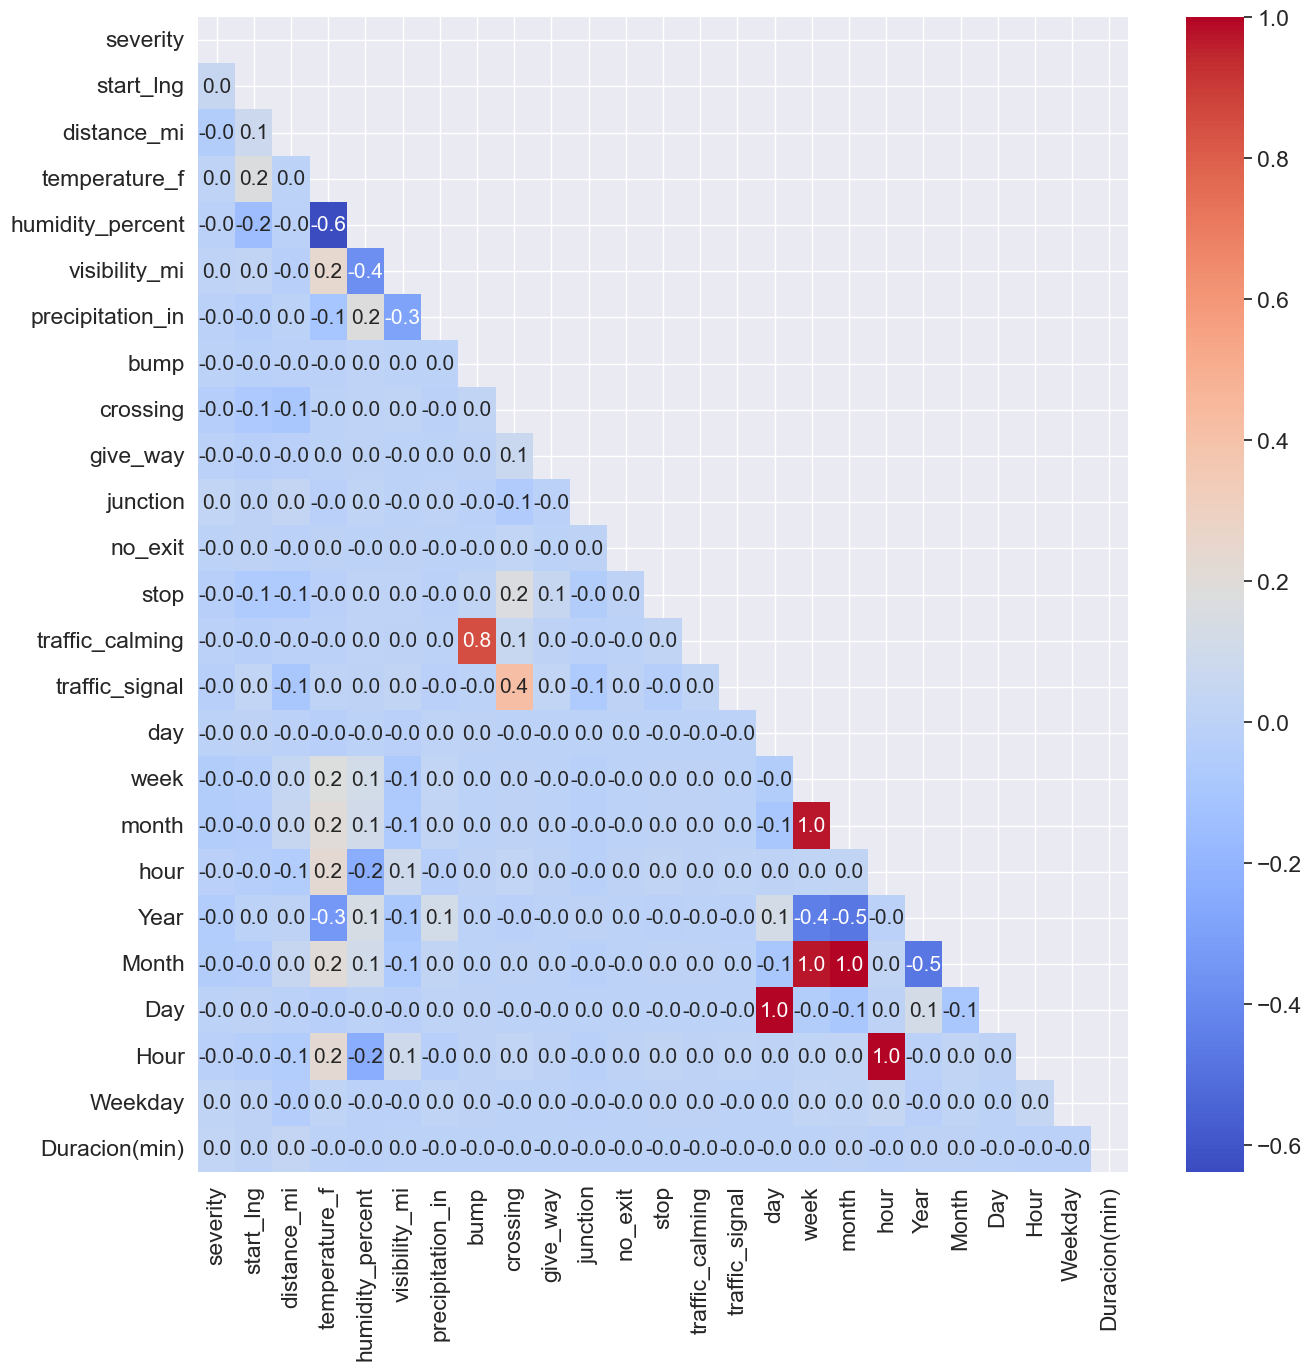

In [259]:
corr_matrix = df.select_dtypes(include=['number']).corr()
import numpy as np
sns.set(font_scale=1.5)
plt.figure(figsize=(15,15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   
sns.heatmap(corr_matrix, mask=mask, cbar=True, fmt='.1f', annot=True, annot_kws={'size': 15}, cmap='coolwarm');

Se elimina la columna de traffic calming porque es explicada por la columna bump, ambas variables hacen referencia a reductores de velocidad.

In [260]:
df.drop(["traffic_calming"],inplace=True,axis=1)

In [261]:
(df.describe().T.round(1))

,count,mean,std,min,25%,50%,75%,max
severity,309079.0,2.0,0.3,1.0,2.0,2.0,2.0,4.0
start_lng,309079.0,-119.5,1.9,-124.4,-121.4,-118.5,-117.9,-114.2
distance_mi,309079.0,1.0,2.1,0.0,0.0,0.3,1.0,50.5
temperature_f,309079.0,63.4,14.5,-8.0,54.0,62.0,72.0,207.0
humidity_percent,309079.0,56.5,24.9,2.0,36.0,58.0,77.0,100.0
visibility_mi,309079.0,9.2,2.4,0.0,10.0,10.0,10.0,100.0
precipitation_in,309079.0,0.0,0.0,0.0,0.0,0.0,0.0,2.1
bump,309079.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
crossing,309079.0,0.1,0.2,0.0,0.0,0.0,0.0,1.0
give_way,309079.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


- **Severity**: 
La mayoría de los accidentes tienen una gravedad de 2, ya que el 50% (mediana) de los datos presentan este valor. 
La gravedad varía entre 1 y 4, siendo 4 la máxima gravedad registrada. 
La desviación estándar es baja (0.2), lo que indica que la mayoría de los accidentes están cerca de la gravedad promedio.

- **Distancia**:
En promedio, la distancia afectada por el accidente es de 1.0 milla, pero hay accidentes que afectan hasta 52.6 millas.

- **Condiciones climáticas**:
La temperatura promedio durante los accidentes es de 63.3°F, con un mínimo de -8.0°F y un máximo sorprendentemente alto de 207.0°F (esto podría ser un error o valor atípico).
La humedad promedio es del 56.6%.
La visibilidad es en promedio de 9.2 millas, con la mayoría de los accidentes teniendo una visibilidad de 10 millas.



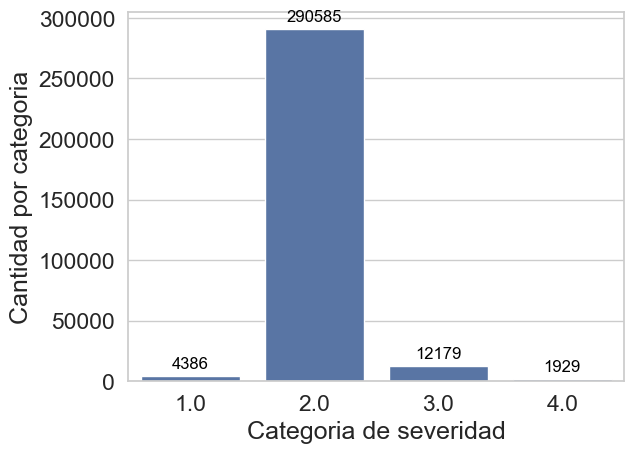

In [262]:
sns.set_style("whitegrid")
ax = sns.countplot(data=df,x="severity")
plt.xlabel("Categoria de severidad")
plt.ylabel("Cantidad por categoria")
def annotate_counts(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=12, color='black', xytext=(0, 9), 
                    textcoords='offset points')
annotate_counts(ax)


Se observa que los datos se encuentran desbalanceados, siendo la mayor frecuencia accidentes de severidad 2. Lo anterior tiene sentido, puesto que los accidentes usualmente no son fatales.

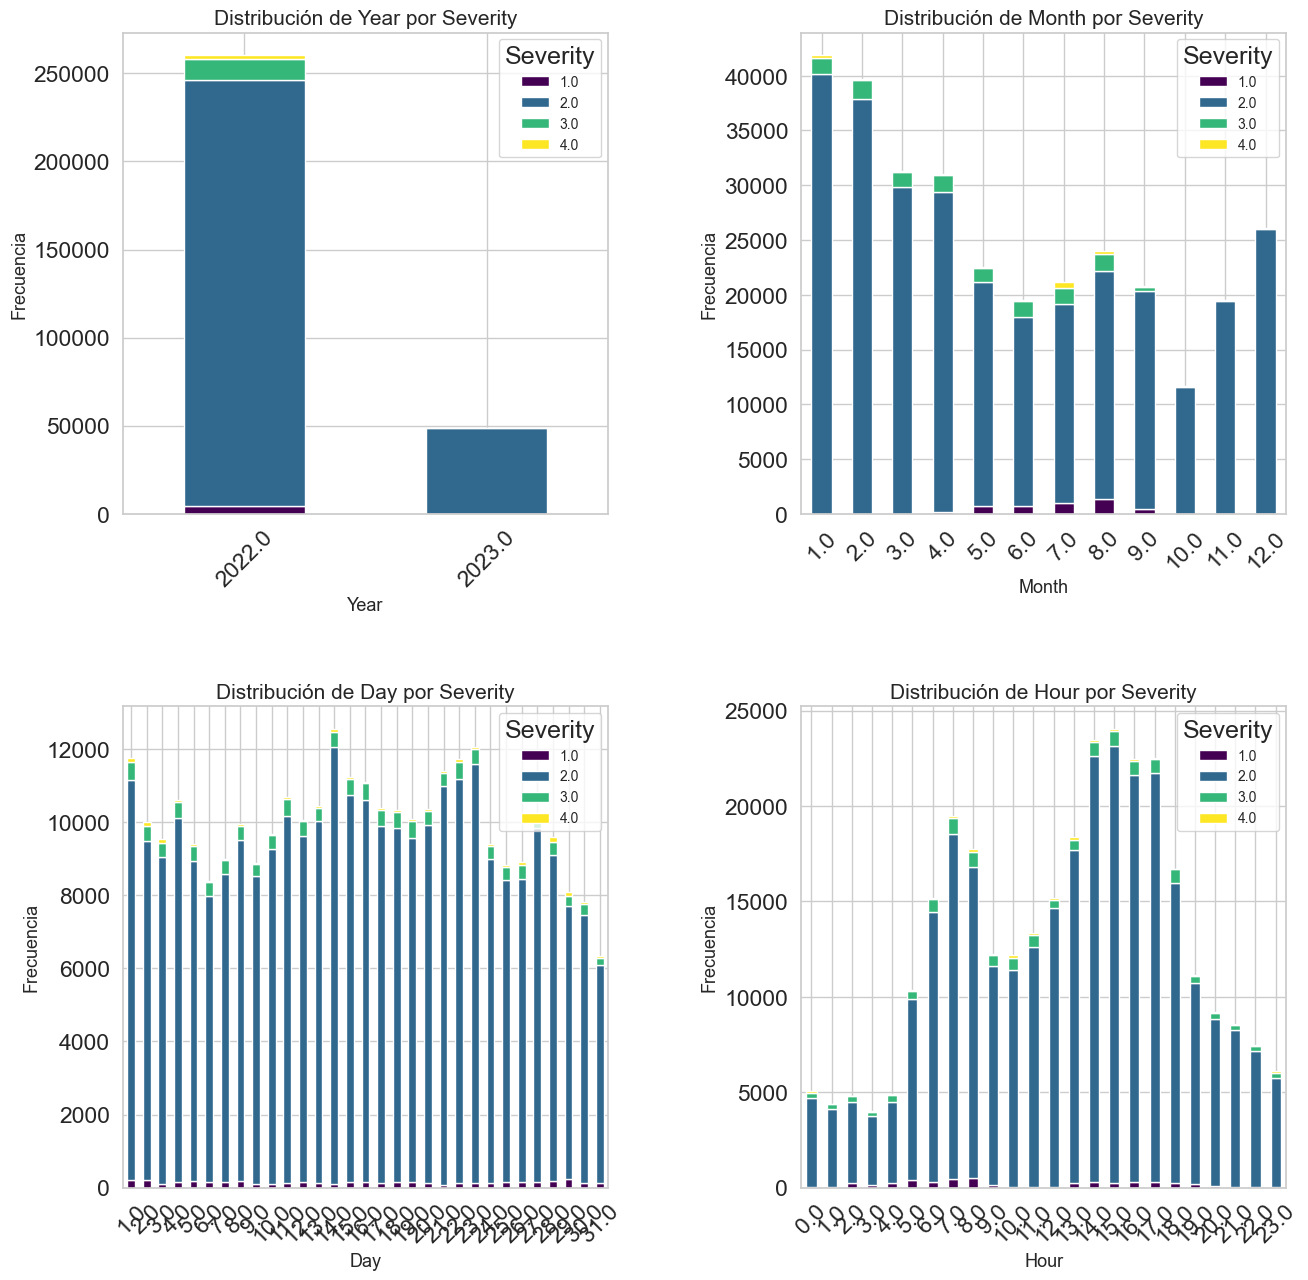

In [263]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))

# Ajustar espacio entre subplots
fig.subplots_adjust(hspace=0.4, wspace=0.4)

columns = ['Year', 'Month', 'Day', "Hour"]

# Crear gráficos de barras apiladas por severity
for idx, column in enumerate(columns):
    row, col = divmod(idx, 2)  # Obtener índices de fila y columna
    pivot_data = df.groupby([column, 'severity']).size().unstack().fillna(0)
    pivot_data.plot(kind='bar', stacked=True, ax=axes[row, col], colormap='viridis')
    
    # Título y etiquetas
    axes[row, col].set_title(f'Distribución de {column} por Severity', fontsize=15)
    axes[row, col].set_ylabel('Frecuencia', fontsize=13)
    axes[row, col].set_xlabel(column, fontsize=13)
    
    # Rotar etiquetas del eje x
    axes[row, col].tick_params(axis='x', rotation=45)
    
    # Mover leyenda
    axes[row, col].legend(title='Severity', loc='upper right', fontsize=10)

# Mostrar gráficos
plt.show()


- Se evidencia que los meses con mayor frecuencia de accidentes son de severidad 2.
- Los meses con mayor frecuencia de accidentes son enero, febrero y marzo.
- El día con mayor incidentes es el 14 del mes según lo observado.
- El rango de horas con mayor accidentalidad es de 14:00 - 17:00 donde usualmente salen de la jornada laboral.